In [185]:
import glob
import os

import pandas as pd
import numpy as np

import tifffile as tf
from tifffile import imread
from tifffile import imwrite

import skimage
from skimage.util import compare_images
from skimage import io, color, measure
from skimage.measure import regionprops
from skimage.measure import label as sk_label  # Renaming the label function to avoid conflicts

import matplotlib.pyplot as plt
import matplotlib

%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [186]:
# Import masks

mask_cell_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Whole_cell/ROIs_as_mask_BIOP'
mask_cell_path = os.path.join(mask_cell_dir,'*.tif') 
mask_cell_files = glob.glob(mask_cell_path)

mask_nucleus_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Nucleus/ROIs_as_mask_BIOP'
mask_nucleus_path = os.path.join(mask_nucleus_dir,'*.tif') 
mask_nucleus_files = glob.glob(mask_nucleus_path)


In [187]:
# Read images into list

mask_cell = []
mask_nucleus = []

for file in mask_cell_files:
    image = imread(file)
    mask_cell.append(image)

for file in mask_nucleus_files:
    image = imread(file)
    mask_nucleus.append(image)

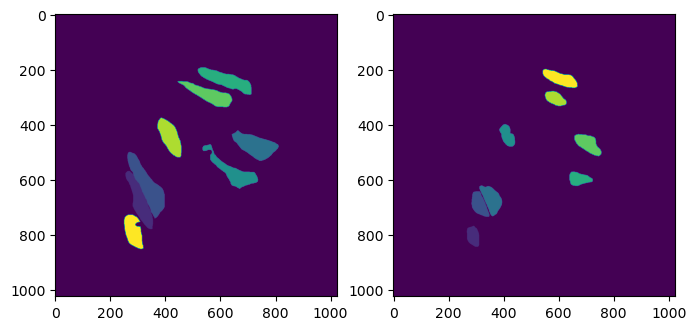

In [188]:
# Plot whole cell and nucleus mask side by side

fig, ax = plt.subplots(1, 2, figsize = (8,4))
ax[0].imshow(mask_cell[3])
ax[1].imshow(mask_nucleus[3])

In [189]:
# To match intensity values of ROIs in nucleus image to intensity values of ROIs in whole cell image

for nucleus_image, cell_image in zip(mask_nucleus, mask_cell):
    # Create a dictionary to store coordinates and corresponding intensity values from mask_cell
    coordinates_intensity = {}

    # Store coordinates and intensity values from cell_image in the dictionary
    for cell_label in regionprops(cell_image):
        for coord in cell_label.coords:
            coordinates_intensity[tuple(coord)] = cell_image[coord[0], coord[1]]

    # Update nucleus_image based on the mapped coordinates and intensity values
    for nucleus_label in regionprops(nucleus_image):
        for coord in nucleus_label.coords:
            if tuple(coord) in coordinates_intensity:
                nucleus_image[coord[0], coord[1]] = coordinates_intensity[tuple(coord)]

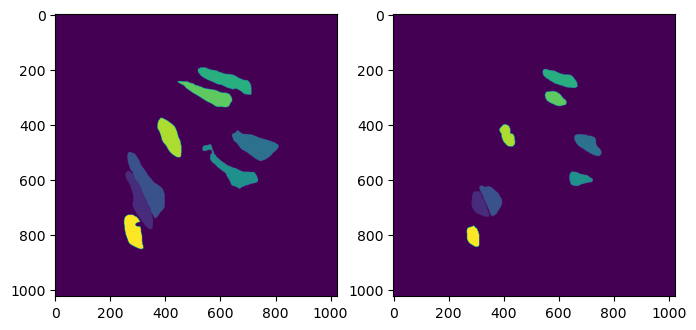

In [190]:
fig, ax = plt.subplots(1, 2, figsize = (8,4))
ax[0].imshow(mask_cell[3])
ax[1].imshow(mask_nucleus[3])

In [191]:
# Substract nucleus mask from cell mask and store as binary cytoplasm mask

mask_cytoplasm = []

for cell, nucleus in zip (mask_cell, mask_nucleus):
    image = skimage.util.compare_images(cell, nucleus)
    mask_cytoplasm.append(image)

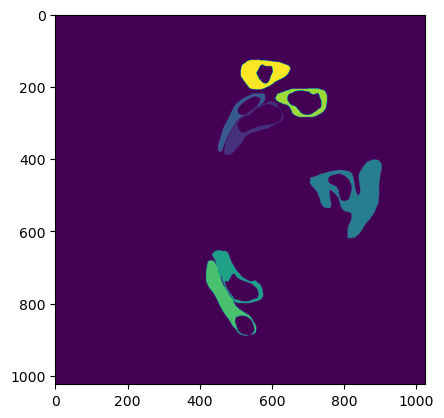

In [192]:
# Plot binary cytoplasm mask

plt.imshow(mask_cytoplasm[2])

In [ ]:
# Assuming 'image' contains the original image with unique intensity values representing regions of interest
# Example: image = np.array([[0, 1, 1, 0], [2, 2, 0, 0], [0, 0, 3, 3]])

mask_cytoplasm_label = []

for image in mask_cytoplasm:

    # Find unique intensity values in the image
    unique_values = np.unique(image)

    # Create an empty array to store the labeled image
    labeled_image = sk_label(image, connectivity=1)

    # Assign labels to regions based on unique intensity values
    for i, val in enumerate(unique_values):
        if val != 0:  # Skip background value (assuming 0 represents background)
            labeled_image[image == val] = i + 1  # Assign label to regions
    
    mask_cytoplasm_label.append(labeled_image)

plt.imshow(mask_cytoplasm_label[0])


In [193]:
# Save cytoplasm masks

mask_cytoplasm_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Cytoplasm/ROIs_as_mask_BIOP'


In [ ]:
for img, tiff_file in zip(mask_cytoplasm_label, mask_cell_files):
    
   # Create the labeled image
    labeled_image = sk_label(img, connectivity=1)

    # Relabel the image to ensure sequential labels starting from 1
    unique_labels = np.unique(labeled_image)
    relabeled_image = np.zeros_like(labeled_image)
    current_label = 1
    for label in unique_labels[1:]:
        relabeled_image[labeled_image == label] = current_label
        current_label += 1

    # Convert the relabeled image to 8-bit (uint8) preserving the labels
    uint8_image = (relabeled_image * (255 / current_label)).astype(np.uint8)

    # Extract the original file name without the extension
    file_name = os.path.splitext(os.path.basename(tiff_file))[0]
    print(file_name)
    
    # Define the output file path
    output_file = os.path.join(mask_cytoplasm_dir, file_name + '.tif')
    print(output_file)
    
    # Save the manipulated image as a TIFF
    tf.imwrite(output_file, uint8_image)

In [194]:
for img, tiff_file in zip(mask_cytoplasm, mask_cell_files):
    
    # Extract the original file name without the extension
    file_name = os.path.splitext(os.path.basename(tiff_file))[0]
    print(file_name)
    
    # Define the output file path
    output_file = os.path.join(mask_cytoplasm_dir, file_name + '.tif')
    print(output_file)
    
    # Save the manipulated image as a TIFF
    tf.imwrite(output_file, img)

100tp_561-100-50ms-1000g_16_conf561_merged_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Cytoplasm/ROIs_as_mask_BIOP/100tp_561-100-50ms-1000g_16_conf561_merged_ROIs.tif
100tp_561-100-50ms-1000g_15_conf561_merged_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Cytoplasm/ROIs_as_mask_BIOP/100tp_561-100-50ms-1000g_15_conf561_merged_ROIs.tif
100tp_561-100-50ms-1000g_18_conf561_merged_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Cytoplasm/ROIs_as_mask_BIOP/100tp_561-100-50ms-1000g_18_conf561_merged_ROIs.tif
100tp_561-100-50ms-1000g_4_conf561_merged_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Cytoplasm/ROIs_as_mask_BIOP/100tp_561-100-50ms-1000g_4_conf561_merged_ROIs.tif
100tp_561-100-50ms-1000g_8_conf561_merged_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Cytoplasm/ROIs_as_mask_BIOP/100tp_561-100-50ms-1000g_